## OBJECTIVE

Analyze the data to know what are the most common words said to the president, whether those are good or bad words and how the perspective of the people would be driven by those

### Text Visualization

1. Text Processing with NLTK
2. Displaying a Word Cloud with nltk and altair

In [1]:
import altair as alt
import pandas as pd

import requests #request to url

# Natural Language Toolkit

import nltk

# downloading some additional packages and corpora

nltk.download('punkt_tab')                 # necessary for tokenization
nltk.download('wordnet')                   # necessary for lemmatization
nltk.download('stopwords')                 # necessary for removal of stop words
nltk.download('averaged_perceptron_tagger_eng')  # necessary for POS tagging
nltk.download('maxent_ne_chunker')         # necessary for entity extraction
nltk.download('omw-1.4')                   # necessary for lemmatization
nltk.download('words')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jairo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jairo\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jairo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\jairo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\jairo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping chunkers\maxent_ne_chunker.zip.
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\jairo\AppData\Roaming\nltk_data...
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\jairo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping

True

### Data

- Data is downloaded from the GitHub link: a story featuring some very interesting people. It doesnt containg emojis, urls, etc.


In [3]:
r = requests.get('https://raw.githubusercontent.com/erickedu85/dataset/master/story.txt')
r.encoding = 'utf-8'
story = r.text
story

'The seventh Sally or how Trurl\'s own perfection led to no good\nBy StanisÅ‚aw Lem, 1965.\nTranslated by Michael Kandel, 1974.\n\nThe Universe is infinite but bounded, and therefore a beam of light, in whatever direction it may travel, will after billions of centuries return -  if powerful enough - to the point of its departure; and it is no different with rumor, that flies about from star to star and makes the rounds of every planet. One day Trurl heard distant reports of two mighty constructor-benefactors, so wise and so accomplished that they had no equal; with this news he ran to Klapaucius, who explained to him that these were not mysterious rivals, but only themselves, for their fame had circumnavigated space. Fame, however, has this fault, that it says nothing of one\'s failures, even when those very failures are the product of a great perfection. And he who would doubt this, let him recall the last of the seven sallies of Trurl, which was undertaken without Klapaucius, whom ce

### Comments:
- Data with structure. If you're working with text from a speech or novel, it might be a good strategy to remove emojis, special characters, and connectors
- If you work with social media—for example, sentiment analysis—it would be helpful to retain certain features, such as emojis.

## Tokenization:
- It is the process of turning a text
into chunks that we can more
easily work with.
- Typically tokenization refers to the
separation and extraction of words.
- It's the space that separates them

In [4]:
from nltk import word_tokenize, pos_tag

words = word_tokenize(story)
words[:20] # showing the first 20 words

['The',
 'seventh',
 'Sally',
 'or',
 'how',
 'Trurl',
 "'s",
 'own',
 'perfection',
 'led',
 'to',
 'no',
 'good',
 'By',
 'StanisÅ‚aw',
 'Lem',
 ',',
 '1965',
 '.',
 'Translated']

## Stemmimg
- A rule-based technique that removes prefixes or suffixes to reduce a word to its stem.
- The resulting stem is not necessarily a valid dictionary word, but it helps group related word forms.

In [5]:
from nltk.stem import PorterStemmer as stemmer # stemming is a process of reducing words to their root form
from nltk.stem import WordNetLemmatizer as lemmatizer # lemmatization is a process of reducing words to their base form
from nltk.corpus import wordnet  # for robust lemmatization

word = "changes" #change, changed, changing, changes

print(stemmer().stem(word))

chang


## Lemmatization
- A linguistically informed technique that reduces inflected words to their lemma (dictionary form) using vocabulary and morphological analysis.
- Unlike stemming, the resulting word is always a valid dictionary word, preserving the word's meaning.
- Minimize information loss.

In [6]:
word = "changing" #change, changed, changing, changes
print(lemmatizer().lemmatize(word, pos=wordnet.VERB)) #  

change


### Part of speech tagging
- Part-of-Speech (POS) Tagging is the process of assigning a grammatical category (e.g., noun, verb, adjective) to each word in a sentence based on its context.

In [7]:
pos = pos_tag(words)
pos[:20] # showing the first 20 words with their POS tags

[('The', 'DT'),
 ('seventh', 'JJ'),
 ('Sally', 'NNP'),
 ('or', 'CC'),
 ('how', 'WRB'),
 ('Trurl', 'NNP'),
 ("'s", 'POS'),
 ('own', 'JJ'),
 ('perfection', 'NN'),
 ('led', 'VBD'),
 ('to', 'TO'),
 ('no', 'DT'),
 ('good', 'JJ'),
 ('By', 'IN'),
 ('StanisÅ‚aw', 'NNP'),
 ('Lem', 'NNP'),
 (',', ','),
 ('1965', 'CD'),
 ('.', '.'),
 ('Translated', 'VBN')]

## Stopwords

- List of default stopwords
- They don't provide any information; They are not relevant to the analysis.
- It is recommended that you remove the stop words.
- Use the language in which the dataset is available.
- We can have our own list of stopwords, for example word used in Ecuador. 

In [8]:
from nltk.corpus import stopwords as stop # TO DO: remove stopwords from the list of words

stopwords = stop.words("spanish") # set language of stopwords to english
stopwords

['de',
 'la',
 'que',
 'el',
 'en',
 'y',
 'a',
 'los',
 'del',
 'se',
 'las',
 'por',
 'un',
 'para',
 'con',
 'no',
 'una',
 'su',
 'al',
 'lo',
 'como',
 'más',
 'pero',
 'sus',
 'le',
 'ya',
 'o',
 'este',
 'sí',
 'porque',
 'esta',
 'entre',
 'cuando',
 'muy',
 'sin',
 'sobre',
 'también',
 'me',
 'hasta',
 'hay',
 'donde',
 'quien',
 'desde',
 'todo',
 'nos',
 'durante',
 'todos',
 'uno',
 'les',
 'ni',
 'contra',
 'otros',
 'ese',
 'eso',
 'ante',
 'ellos',
 'e',
 'esto',
 'mí',
 'antes',
 'algunos',
 'qué',
 'unos',
 'yo',
 'otro',
 'otras',
 'otra',
 'él',
 'tanto',
 'esa',
 'estos',
 'mucho',
 'quienes',
 'nada',
 'muchos',
 'cual',
 'poco',
 'ella',
 'estar',
 'estas',
 'algunas',
 'algo',
 'nosotros',
 'mi',
 'mis',
 'tú',
 'te',
 'ti',
 'tu',
 'tus',
 'ellas',
 'nosotras',
 'vosotros',
 'vosotras',
 'os',
 'mío',
 'mía',
 'míos',
 'mías',
 'tuyo',
 'tuya',
 'tuyos',
 'tuyas',
 'suyo',
 'suya',
 'suyos',
 'suyas',
 'nuestro',
 'nuestra',
 'nuestros',
 'nuestras',
 'vuestro'

## Data cleaning

1. Tokenize
2. Remove numbers, URLs, mentions, and emojis (if applicable).
3. Keep the tokens that are not on the stopword list

In [ ]:
tokens = nltk.word_tokenize(story.lower()) # tokenize the story and convert to lowercase to compare with stopwords

# tokens that contain only letters
lettertokens = [word for word in tokens if word.isalpha()]

# remove stopwords
without_stopwords = [
  word for word in lettertokens
  if word not in stopwords
]

without_stopwords[:20]

['the',
 'seventh',
 'sally',
 'or',
 'how',
 'trurl',
 'own',
 'perfection',
 'led',
 'to',
 'good',
 'by',
 'lem',
 'translated',
 'by',
 'michael',
 'kandel',
 'the',
 'universe',
 'is']

### Bag-of-words (BOW)
- The next step is to convert the text into a numerical representation that can be used by analysis and machine learning algorithms.
- One of the simplest and most widely used representations is Bag-of-Words (BoW), which tracks which words appear and how many times they appear.
- List of Dictionaries: unique word and the number of occurrences

In [ ]:
# bag of words as a dictionary data type
bow = {}

# occurrences of each word in the list of words without stopwords
for word in without_stopwords:
  bow[word] = words.count(word)

# sorted list of word-frequency tuples
words_frequency = sorted(
  bow.items(),
  key=lambda x: x[1], # sort by frequency
  reverse=True # sort in descending order
)

words_frequency[:20] # showing the first 20 words with their frequencies

[('the', 162),
 ('of', 128),
 ('and', 105),
 ('to', 63),
 ('that', 58),
 ('in', 47),
 ('it', 29),
 ('his', 29),
 ('you', 29),
 ('was', 25),
 ('with', 24),
 ('they', 24),
 ('for', 22),
 ('not', 20),
 ('as', 19),
 ('by', 18),
 ('this', 18),
 ('do', 18),
 ('all', 17),
 ('but', 16)]

### Word Cloud
- Each word's frequency is displayed in a word cloud based on its frecuency
- The main character of the story is mentioned several times
- One of the goals is to ensure that there is no overlap between words
- No with Altair
- General idea of what your text file looks like

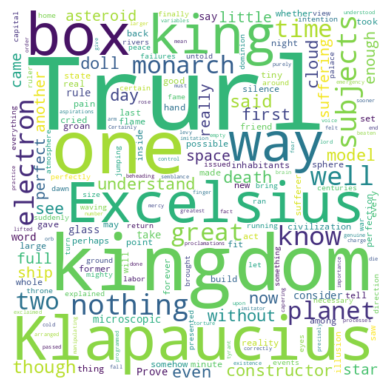

In [11]:
from wordcloud import WordCloud # importing the WordCloud class from the wordcloud module
import matplotlib.pyplot as plt # importing the pyplot module from the matplotlib library

wc = WordCloud( # creating a WordCloud object
    width=500,
    height=500,
    background_color='white'
).generate(story) # generating the word cloud from the story text

plt.figure()
plt.imshow(wc, interpolation='bilinear') # displaying the word cloud image
plt.axis('off') # hiding the axes
plt.show()

### Bar charts

In [12]:
# dataframe from the word frequencies
df = pd.DataFrame(words_frequency, columns=['word', 'count'])

# focus on the top 20 words
df_top = df[:20]

# horizontal barchart
alt.Chart(df_top).mark_bar().encode( # encoding the chart
    alt.X('count'), # encoding the x-axis with the count of words
    alt.Y('word', sort='-x') # encoding the y-axis with the words, sorted by count in descending order
)

alt.Chart(...)

### With Altair
- Identify word categories based on word count

In [13]:
words = [] # list to hold the words
types = [] # list to hold the types of words

# iterate over all entries in the Part-Of-Speech POS list
for p in pos: # p is a tuple of (word, tag)
    word = p[0].lower()  # get the word
    tag = p[1]           # get the word's type

    if word.isalpha() and word not in stopwords: # check if the word is alphabetic and not a stopword
        words.append(word)  # add this word to the word list

        # add its word type to types list
        if tag.startswith('N'): # check if the tag starts with 'N' for Noun
            types.append('Noun')
        elif tag.startswith('V'): # check if the tag starts with 'V' for Verb
            types.append('Verb')
        elif tag.startswith('J'): # check if the tag starts with 'J' for Adjective
            types.append('Adjective')
        elif tag.startswith('R'): # check if the tag starts with 'R' for Adverb
            types.append('Adverb')
        else:
            types.append('Other') # add 'Other' for any other type of word

# words[:20] # showing the first 20 words
types[:20] # showing the first 20 types


['Other',
 'Adjective',
 'Noun',
 'Other',
 'Other',
 'Noun',
 'Adjective',
 'Noun',
 'Verb',
 'Other',
 'Adjective',
 'Other',
 'Noun',
 'Verb',
 'Other',
 'Noun',
 'Noun',
 'Other',
 'Noun',
 'Verb']

### Dataframe with counts words and types
- Number of occurrences by category

In [14]:
# create a dataframe from the words and their types
df = pd.DataFrame({'word': words, 'type': types})

# base of two sub-charts
base = alt.Chart(df)

# filter selection
selection = alt.selection_point(fields=['type']) 

# condition for opacity based on selection
opacity_condition = alt.condition(
    selection,
    alt.value(1), # opacity for selected items
    alt.value(0.1) # opacity for non-selected items
)

# chart1  
chart1 = base.mark_bar().encode(
    alt.X('type', sort='-y'), # sorting the x-axis by count in descending order
    alt.Y('count()'), # encoding the y-axis with the count of words
    opacity=opacity_condition
).add_params(selection) # adding the selection parameter

# chart2
chart2 = base.mark_bar(width=5).encode(
    alt.X('word', sort='-y'),
    alt.Y('count()')
).transform_filter(selection) # filtering the data based on the selection in chart1

chart1 | chart2 # displaying the charts side by side

alt.HConcatChart(...)

- More nouns than any other type of category